# 1. 라이브러리, 2. 토크나이저

## 1-1. Import

In [1]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

# torch version
print(torch.__version__)

2.5.1+cu121


## 2-1. 센텐스피스 토큰화

In [ ]:
import sentencepiece as spm
import os

# 코퍼스 파일 이름 (환경에 따라 kowiki.txt 등이 될 수 있습니다)
# 만약 기존에 쓰시던 텍스트 파일 이름이 다르다면 'kowiki.txt' 부분만 수정해 주세요.
corpus_file = './data/kowiki.txt/kowiki.txt' 
vocab_size = 8000
model_prefix = f"ko_{vocab_size}"
model_file = f"{model_prefix}.model"

# [수정됨]: 모델 파일(ko_8000.model)이 이미 존재하는지 검사하는 조건문 추가
if os.path.exists(model_file):
    print(f"✅ '{model_file}' 파일이 이미 존재합니다. 토크나이저 학습을 건너뛰고 기존 모델을 유지합니다.")
else:
    print(f"[{corpus_file}] 파일로 SentencePiece 모델 학습을 시작합니다. (vocab_size: {vocab_size})")
    print("시간이 조금 걸릴 수 있습니다. 잠시만 기다려주세요...")

    # SentencePiece 모델 학습 명령
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} "              # 1. 이 텍스트 파일(Kowiki.txt)을 줄게! 이걸 읽어봐.
        f"--model_prefix=ko_{vocab_size} "     # 2. 다 끝나면 'ko_8000'이라는 이름으로 파일 저장해줘.
        f"--vocab_size={vocab_size + 7} "      # 3. 텍스트를 통계적으로 쪼개서, 너만의 사전에 딱 8,007개의 덩어리(토큰)만 등록해.
        f"--pad_id=0 --pad_piece=[PAD] "       # 4. (특수 기호 번호 부여) 빈 공간 채울 때는 0번 [PAD] 써!
        f"--unk_id=1 --unk_piece=[UNK] "       # 5. 사전에 없는 모르는 단어 나오면 에러 뱉지 말고 1번 [UNK]로 퉁쳐.
        f"--bos_id=2 --bos_piece=[BOS] "       # 6. 문장의 시작은 2번 [BOS]!
        f"--eos_id=3 --eos_piece=[EOS] "       # 7. 문장의 끝은 3번 [EOS]!
        f"--user_defined_symbols=[SEP],[CLS],[MASK] " # 8. BERT 모델 쓸 거니까 [SEP], [CLS], [MASK] 이 세 개도 특수 기호로 추가해줘. (번호는 자동으로 4, 5, 6번이 됨)
        f"--model_type=bpe "                   # 9. 쪼개는 방식은 BPE(Byte Pair Encoding: 통계적으로 자주 나오는 걸 묶는 방식)로 해.
        f"--max_sentence_length=32768"         # 10. 한 문장이 너무 길면 32768자까지만 읽고 잘라.
    )


    print(f"✅ 학습 완료! 'ko_{vocab_size}.model' 파일과 'ko_{vocab_size}.vocab' 파일이 성공적으로 생성되었습니다.")

✅ 'ko_8000.model' 파일이 이미 존재합니다. 토크나이저 학습을 건너뛰고 기존 모델을 유지합니다.


## 2-2. 학습시킨 토크나이저 모델 불러오기

In [3]:
vocab = spm.SentencePieceProcessor()
vocab.load("ko_8000.model")

True

In [4]:
# 2. Random Masking을 위해 특수 토큰(0~6번)을 제외한 일반 단어장(vocab_list) 생성
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))
print(vocab_list)

['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁지', '▁수', '▁19', '▁가', '▁시', '▁20', '▁기', '▁전', '▁아', '▁하', '▁있다', '▁다', '▁제', '했다', '하였', '▁일', '▁한', '▁중', '▁정', '▁주', '하는', '▁것', '▁자', '▁공', '▁인', '되었다', '▁경', '▁위', '▁유', '▁보', '하고', '▁3', '▁등', '▁부', '하였다', '▁조', '하여', '▁미', '▁동', '▁선', '▁나', '으며', '▁모', '▁연', '▁영', '▁의', '▁오', '▁마', '에는', '▁발', '▁소', '한다', '▁고', '▁개', '▁201', '▁구', '▁세', '▁도', '▁상', '▁비', '▁스', '▁국', '▁서', '▁후', '▁여', '▁200', '▁때', '▁4', '▁성', '▁해', '▁관', '▁있는', '▁신', '▁프', '▁대한', '부터', '▁5', '00', '▁방', '▁또', '지만', '▁(', '▁역', '되어', '▁않', '▁만', '▁"', '▁장', '▁바', '까지', '▁무', '▁남', '▁통', '▁현', '▁교', '▁같', '에게', '▁내', '학교', '▁문', '▁출', '▁거', '▁포', '▁결', '된다', '▁《', '적인', '이라', '▁6', '▁우', '적으로', '▁불', '▁원', '▁최', '▁진', '▁생', '▁작', '▁어', '▁당', '국의', '▁노', '▁강', '▁알', '▁반', '▁7', '▁8', '▁계', '▁따', '▁파', '▁분', '▁없', '▁받', '▁말', '면서', '들이', 'or', '되었', '▁사용', "▁'", '▁두', '▁실', '에서는', '▁10', '▁리', '들은', '▁명', '▁함', '▁단', '▁이후', '하기', '▁예', '년에', '),',

# 3. 데이터 전처리

## 3-1. 마스크 생성

### 3-1-1. MaskedLM을 위한 코퍼스 생성

In [ ]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 띄어쓰기 단위로 mask 하기 위해서 index 분할
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

### 3-1-2. create_pretrain_mask() 수행 결과

In [6]:
# [추가됨]: 지워진 연습용 셀에 있던 테스트용 원본 토큰과 마스크 개수 변수 복구
sample_text = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아"
tokens_org = [vocab.id_to_piece(id) for id in vocab.encode_as_ids(sample_text)]
tokens_org = ["[CLS]"] + tokens_org + ["[SEP]"] # BERT 형식으로 앞뒤에 특수 토큰 추가
mask_cnt = int((len(tokens_org) - 2) * 0.15)    # 전체 토큰의 15% 계산

# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]'] 

tokens
['[CLS]', '▁추', '적', '추', '적', '[MASK]', '[MASK]', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]'] 

mask_idx   : [5, 6]
mask_label : ['▁비', '가']


## 3-2. NSP pair 생성

- Next Sentence Prediction
- 문장 2개를 붙여 놓고 이어지는 것인지 아닌지
- `True` or `False`

### 3-2-1. NSP 코퍼스 생성 함수

In [ ]:
import random

def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    BERT의 NSP(Next Sentence Prediction)와 MLM을 동시에 수행하기 위한 데이터 생성 함수
    """
    # [CLS], [SEP], [SEP] 특수 토큰이 들어갈 3자리를 미리 빼둠
    max_seq = n_seq - 3 
    
    instances = []
    current_chunk = []
    current_length = 0

    # 문서를 한 줄 씩 읽어서 chunk에 담고, 몇 줄인지 측정
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        # 현재 모인 문장 길이(current_length)가 최대 길이(max_seq:128)를 채웠거나, 문서의 끝에 도달했을 때
        if i == len(doc) - 1 or current_length >= max_seq:
            # 문서 장바구니(chunk)에 데이터가 담겨 있을 때 (안전장치)
            if current_chunk:
                # [수정됨]: 지침에 따라 50% 확률로 두 문장이 이어지는지(True), 아닌지(False) 결정
                is_next = random.random() < 0.5 
                
                # 자르는 위치(a_end) 기본값은 1 (즉, 문장이 하나면 무조건 첫번째 문장만 A가 됨)
                a_end = 1
                # 모인 문장 덩어리 안에 문장이 2개 이상 들어있다면?
                if len(current_chunk) > 1:
                    # 1부터 전체 문장 개수 사이에서 아무 위치나 무작위로 하나 뽑기!
                    a_end = random.randrange(1, len(current_chunk))
                    
                tokens_a = []
                for j in range(a_end):
                    tokens_a.extend(current_chunk[j])
                    
                tokens_b = []
                
                # False 케이스: 문서 내의 다른 무작위 문장을 가져와서 이어지지 않게 만듦
                if not is_next and len(doc) > 1:
                    random_idx = random.randrange(0, len(doc))
                    tokens_b.extend(doc[random_idx])
                # True 케이스: 원래 순서대로 이어지게 만듦
                else:
                    is_next = True 
                    for j in range(a_end, len(current_chunk)):
                        tokens_b.extend(current_chunk[j])

                # 1. 토큰 합치기: [CLS] + 문장 A + [SEP] + 문장 B + [SEP]
                tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
                
                # 2. Segment 처리: 지침에 따라 첫 번째 문장(A)은 0, 두 번째 문장(B)은 1로 채움
                segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

                # 3. MLM 적용: 앞서 완성한 마스킹 함수 호출
                mask_cnt = int((len(tokens) - 3) * mask_prob) 
                tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

                # 최종적으로 완성된 1세트의 학습 데이터 저장
                instances.append({
                    "tokens": tokens,
                    "segment": segment,
                    "is_next": is_next,
                    "mask_idx": mask_idx,
                    "mask_label": mask_label
                })
            
            # 다음 묶음을 위해 초기화
            current_chunk = []
            current_length = 0

    return instances

print("✅ create_pretrain_instances 함수 정의 완료! (NSP 및 Segment 처리 완벽 반영)")

✅ create_pretrain_instances 함수 정의 완료! (NSP 및 Segment 처리 완벽 반영)


## 3-3. 데이터셋 완성

### 3-3-1. BERT pretrain 데이터셋 생성 함수

In [9]:
# Q. 아래 주석에 따라 코드를 완성해주세요.
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

> 생성된 데이터셋은 json 포맷으로 저장

In [10]:
pretrain_json_path = 'bert_pre_train.json'

make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)


  0%|          | 0/3957761 [00:00<?, ?it/s]

> json 파일 라인 수

In [11]:
# 라인수
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
total

1095770

### 3-3-2. load_pre_train_data() : 학습에 필요한 데이터를 로딩하는 함수

In [ ]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            if count is not None and count <= total:
                break

    # 1번째 그릇 (원본 문제지): 128칸짜리 단어 번호
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    
    # 2번째 그릇 (문장 구분선): 128칸짜리 0과 1의 라벨
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    
    # 3번째 그릇 (NSP 정답지): 문장이 이어지는지 여부 (Yes:1 / No:0). 이건 128칸이 필요 없고 각 문제당 딱 1칸짜리 정답 하나만 필요해서 길이가 shape=(total,) 입니다.
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    
    # 4번째 그릇 (MLM 정답지): 빈칸에 들어갈 128칸짜리 원래 단어 번호
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            
            # 1. encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token = enc_token[:n_seq]  # [수정됨]: 128(n_seq)을 넘어가면 뒷부분을 잘라냅니다.
            enc_token += [0] * (n_seq - len(enc_token))
            
            # 2. segment
            segment = data["segment"]
            segment = segment[:n_seq]      # [수정됨]: 128(n_seq)을 넘어가면 뒷부분을 잘라냅니다.
            segment += [0] * (n_seq - len(segment))
            
            # nsp label
            label_nsp = data["is_next"]
            
            # 3. mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            
            # [수정됨]: 위에서 문장을 잘라냈으므로, 128번 위치 밖에 있던 마스크 정답도 같이 버립니다.
            # [방어 코드]: 만약 앞선 공정 오류로 문장이 128칸(n_seq) 이상으로 길어서 잘려 나갔다면,
            # 128번 칸 바깥쪽에 위치했던 빈칸(MASK)의 문제와 정답지(Label)도 함께 무효화(삭제)해야 함!
            
            # 예: mask_idx 상태: [12, 135]
            # 1. 각 빈칸의 위치 번호가 128(n_seq) 미만인지 검사하는 T/F 판별기 생성 (예: [True, False])
            valid_mask = mask_idx < n_seq
            # 2. 판별기를 덧씌워서 True인 인덱스(128 미만 위치)만 남기고, 벗어난 위치의 문제는 삭제!
            mask_idx = mask_idx[valid_mask]     # mask_idx 결과: [12]
            # 3. 문제가 삭제되었으니, 그 문제의 정답(Label)도 짝을 맞춰서 같이 삭제!
            mask_label = mask_label[valid_mask]
            
            # 처음에 128칸에 전부 숫자 0(정답 아님)으로 찍습니다.
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            # 그리고 실제 뚫린 자리(mask_idx) 칸에만 원래 정답(mask_label 숫자)을 넣어줍니다.
            label_mlm[mask_idx] = mask_label

            # 이제 무조건 길이가 128로 동일해져서 AssertionError가 발생하지 않습니다!
            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

> 128000건만 메모리에 로딩

In [15]:
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=128000)

  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000


> 처음과 마지막 확인

In [16]:
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(memmap([   5,   18, 3686,  207, 3714,    4, 3324, 1042,  104, 3610, 3686,
         3718,  207, 3714,   37, 3417,  416,  810, 3666, 3625,  160, 3662,
            7, 3629,  203,  241, 3602,    6,    6,    6,  243,   49, 3632,
          796,  663, 1648, 3682, 3682, 3625,  203, 3009, 3625, 3616,   16,
         3599,   18, 3686,  207, 3714, 3602, 1756, 3630, 3646,  630, 3714,
         3568, 3835,    6,    6,    6,    6, 1370,   10, 1607, 3599, 1756,
         3630,   41, 3644,  830, 3624, 1135,   52, 3599,   13,   81,   87,
         1502, 2247, 6322,  915, 7846, 4346, 1163, 5499, 2508, 3727,  331,
         3416, 2274,  249, 3725, 1233,    6,    6,    6,  479, 3652, 3625,
          243, 2780,   14, 1510,  168, 3877,  414,  166, 1697, 4290, 3873,
         3703, 3683,  593,   21, 5007,  399, 1928, 3607,  813,   17, 3599,
          307,  587,  930,  104, 4313, 4290,  613], dtype=int32),
 memmap([   5,   21, 3941, 3635,   29, 3603,    4, 1025, 3652, 3625, 3604,
           21, 3941, 3635,   49, 3

# 4. BERT 모델 구현

## 4-1. 유틸리티 함수 정의

### 4-1-1. pad, ahead mask

In [17]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

print("슝=3")

슝=3


### 4-1-2. GELU 함수

In [18]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

print("슝=3")

슝=3


### 4-1-3. parameter, bias initializer

In [19]:
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_

def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_

print("슝=3")

슝=3


### 4-1-4. json - config

In [20]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
print("슝=3")

슝=3


## 4-2. 임베딩 레이어

### 4-2-1. 토큰 임베딩

In [21]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs
print("슝=3")

슝=3


### 4-2-2. 포지션 임베딩

In [22]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

print("슝=3")

슝=3


## 4-3. 모델 구현

### 4-3-1. ScaleDotProductAttention

In [23]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

print("슝=3")

슝=3


### 4-3-2. MultiHeadAttention

In [24]:
# Q. 주석과 코드를 참조하여 아래 클래스를 완성해주세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out
print("슝=3")

슝=3


### 4-3-3. PositionWiseFeedForward

In [25]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("슝=3")

슝=3


### 4-3-4. EncoderLayer

In [26]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("슝=3")

슝=3


### 4-3-5. BERT layer

In [27]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

print("슝=3")

슝=3


### 4-3-6. PooledOutput

In [28]:
# Encoder Layer class 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: softmax된 결과
        """
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        outputs = F.softmax(outputs, dim=-1)
        return outputs

print("슝=3")

슝=3


### 4-3-7. PreTrainModel

In [29]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_cls = self.pooled_output(logits_cls)
        outputs_nsp = F.softmax(logits_cls, dim=-1)

        outputs_mlm = F.softmax(logits_lm, dim=-1)
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("슝=3")

슝=3


### 4-3-8. Config

In [30]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

# [수정됨]: 전체 파라미터가 약 1.3M(약 100만) 개가 되도록 mini BERT 구조로 하이퍼파라미터 대폭 축소
config = Config({
    "d_model": 128,      # [수정됨]: 임베딩 및 은닉층 크기 축소
    "n_head": 4,         # 어텐션 헤드 수
    "d_head": 32,        # [수정됨]: d_model(128) / n_head(4) = 32로 맞춰줌
    "dropout": 0.1,
    "d_ff": 256,         # [수정됨]: 피드포워드 네트워크 크기 축소 (기존 1024 -> 256)
    "layernorm_epsilon": 0.001,
    "n_layer": 2,        # [수정됨]: 레이어 개수를 2개로 줄여 1M 사이즈 달성
    "n_seq": 128,        # 우리가 앞서 전처리에서 맞춘 길이 (128)
    "n_vocab": 0,        # [수정됨]: 이 부분은 아래에서 실제 단어장 크기로 자동 세팅합니다.
    "i_pad": 0
})

# [수정됨]: 기존 코드에 있던 불필요한 가짜 Vocab 클래스 생성 부분을 삭제하고, 
# 우리가 위에서 힘들게 만든 '진짜' SentencePiece vocab의 크기(8007)를 그대로 사용하도록 연결합니다.
config.n_vocab = len(vocab)
config.i_pad = vocab.pad_id() 

print(f"✅ 미니 BERT Config 설정 완료! (단어장 크기: {config.n_vocab})")

✅ 미니 BERT Config 설정 완료! (단어장 크기: 8007)


### 4-3-9. 데이터로드

In [31]:
n_seq = 10

# make test inputs
enc_tokens = torch.randint(0, config.n_vocab, (10, n_seq))
segments = torch.randint(0, 2, (10, n_seq))
labels_nsp = torch.randint(0, 2, (10,))
labels_mlm = torch.randint(0, config.n_vocab, (10, n_seq))

batch_size = 5
train_dataset = TensorDataset(enc_tokens, segments, labels_nsp, labels_mlm)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

### 4-3-10. 학습 루프

In [32]:
# 모델 불러오기
model = build_model_pre_train(config)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 학습 루프
epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()
        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, config.n_vocab), labels_mlm_batch.view(-1))
        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()

        total_loss_batch.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}")

Epoch 1/2 - Loss: 9.659930229187012
Epoch 2/2 - Loss: 9.65467643737793


# 5. Pretrain 진행

## 5-1. LOSS, Accuracy

### 5-1-1. lm_loss

In [33]:
def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # loss 계산
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    loss = loss * mask
    return loss.mean() * 20   # mlm을 더 잘 학습하도록 20배 증가 시킴

print("슝=3")

슝=3


### 5-1-2. lm_acc

In [34]:
def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

print("슝=3")

슝=3


## 5-2. Learning Rate

In [35]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        return self.get_lr()

print("슝=3")

슝=3


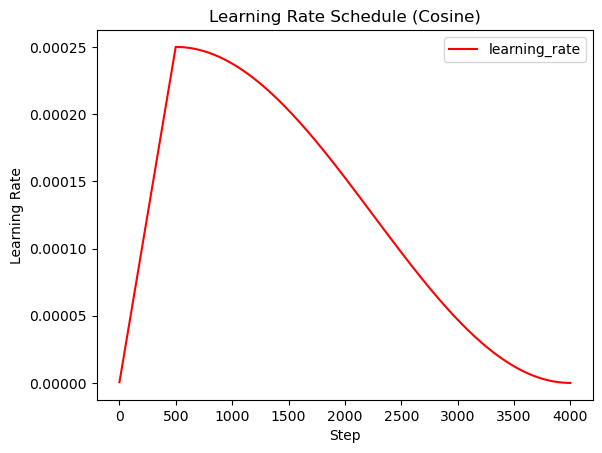

In [36]:
# compute lr
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

## 5-3. 모델 인스턴스 생성

In [41]:
# 모델 생성
from torchinfo import summary

config.n_seq = 128
pre_train_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            1,024,896
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 128]       

## 5-4. optimizer

In [42]:
# [수정됨]: 지침에 따라 학습 횟수를 10 Epoch로 늘렸습니다.
epochs = 10
batch_size = 64

# optimizer
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)

learning_rate_scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps // 10))
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
# [수정됨]: MLM 빈칸 추론 시, 의미 없는 빈 공간(PAD, 0번)은 정답 채점에서 제외하도록 안전장치를 추가했습니다.
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)

train_steps: 20000


## 5-5. 학습 루프

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [46]:
# [수정됨]: 데이터가 이미 GPU용 텐서인지 확인하는 안전장치 추가 (에러 완벽 방지)
if not torch.is_tensor(pre_train_inputs[0]):
    pre_train_inputs = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
    pre_train_labels = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]

train_dataset = TensorDataset(pre_train_inputs[0], pre_train_inputs[1], pre_train_labels[0], pre_train_labels[1])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

pre_train_model.to(device)

history = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc': [],
    'mlm_acc': []
}

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}"):
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()
        
        # [수정됨]: 루프가 한 번 돌 때마다 지침대로 Learning Rate를 스케줄러에 맞게 업데이트합니다.
        lr = learning_rate_scheduler.step()
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc = (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean()

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # 결과 저장
    history['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader):.4f}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader):.4f}, MLM Loss: {total_mlm_loss / len(train_dataloader):.4f}, "
          f"NSP Acc: {total_nsp_acc / len(train_dataloader):.4f}, MLM Acc: {total_mlm_acc / len(train_dataloader):.4f}")

    # 모델 저장
    torch.save(pre_train_model.state_dict(), f"bert_pre_train_epoch_{epoch+1}.pt")

Epoch 1:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 9.6603, NSP Loss: 0.6875, MLM Loss: 8.9728, NSP Acc: 0.5343, MLM Acc: 0.0024


Epoch 2:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 9.6236, NSP Loss: 0.6606, MLM Loss: 8.9630, NSP Acc: 0.6015, MLM Acc: 0.0032


Epoch 3:   0%|          | 0/2000 [00:00<?, ?it/s]

...

Epoch 8/10 - Loss: 9.6119, NSP Loss: 0.6490, MLM Loss: 8.9629, NSP Acc: 0.6304, MLM Acc: 0.0032


Epoch 9:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 9.6108, NSP Loss: 0.6479, MLM Loss: 8.9629, NSP Acc: 0.6349, MLM Acc: 0.0032


Epoch 10:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 9.6099, NSP Loss: 0.6471, MLM Loss: 8.9629, NSP Acc: 0.6360, MLM Acc: 0.0032


## 5-6. 시각화

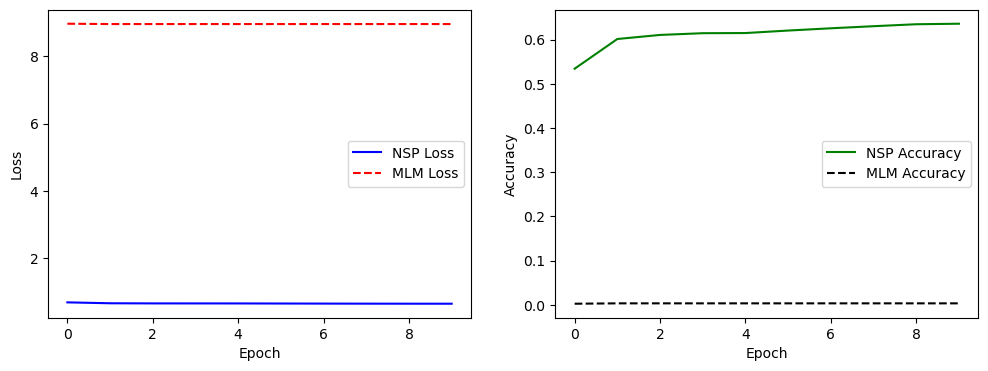

In [47]:
import matplotlib.pyplot as plt

# training result
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()